In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
BASE_DIR = Path('../data').resolve().parent
BASE_DIR

WindowsPath('D:/1_IUH/4_HK2_2025_2026/CNM/Project/Code')

## Train Data

In [4]:
train_df = pd.read_csv(BASE_DIR / 'data' / 'train_v2.csv')

train_df.head(3)

,msno,is_churn
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1


In [5]:
train_df.shape

(970960, 2)

In [6]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 970960 entries, 0 to 970959
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   msno      970960 non-null  str  
 1   is_churn  970960 non-null  int64
dtypes: int64(1), str(1)
memory usage: 14.8 MB


In [7]:
train_df.is_churn.value_counts()

is_churn
0    883630
1     87330
Name: count, dtype: int64

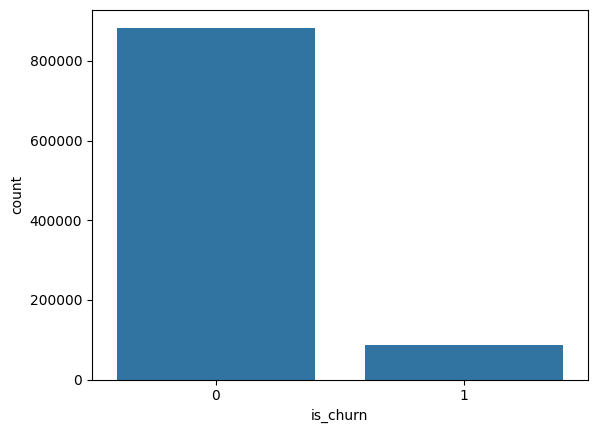

In [8]:
sns.countplot(x='is_churn', data=train_df)
plt.show()

In [9]:
train_df.msno.nunique()

970960

## Transaction

In [10]:
transactions_df = pd.read_csv(BASE_DIR / 'data' / 'transactions_v2.csv')

transactions_df.head(3)

,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,++6eU4LsQ3UQ20ILS7d99XK8WbiVgbyYL4FUgzZR134=,32,90,298,298,0,20170131,20170504,0
1,++lvGPJOinuin/8esghpnqdljm6NXS8m8Zwchc7gOeA=,41,30,149,149,1,20150809,20190412,0
2,+/GXNtXWQVfKrEDqYAzcSw2xSPYMKWNj22m+5XkVQZc=,36,30,180,180,1,20170303,20170422,0


In [11]:
transactions_df.shape

(1431009, 9)

In [12]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1431009 entries, 0 to 1431008
Data columns (total 9 columns):
 #   Column                  Non-Null Count    Dtype
---  ------                  --------------    -----
 0   msno                    1431009 non-null  str  
 1   payment_method_id       1431009 non-null  int64
 2   payment_plan_days       1431009 non-null  int64
 3   plan_list_price         1431009 non-null  int64
 4   actual_amount_paid      1431009 non-null  int64
 5   is_auto_renew           1431009 non-null  int64
 6   transaction_date        1431009 non-null  int64
 7   membership_expire_date  1431009 non-null  int64
 8   is_cancel               1431009 non-null  int64
dtypes: int64(8), str(1)
memory usage: 98.3 MB


In [13]:
transactions_df.payment_method_id.unique()

array([32, 41, 36, 40, 16, 34, 39, 38, 33, 30, 12, 20, 15, 29, 37, 13, 31,
       19, 22, 21, 17, 35, 14, 23, 27, 28, 18,  6, 26,  8, 11,  3, 10, 24,
       25,  5,  2])

In [14]:
transactions_df.payment_plan_days.unique()

array([ 90,  30, 410, 180, 195, 100, 365, 395, 360, 240,   0, 450,   7,
       200,  60, 120, 415, 400, 270,  31,   1,  14,  10,  80,  70,  45,
        35, 230,   3, 110,  21])

In [15]:
transactions_df.is_auto_renew.value_counts()

is_auto_renew
1    1123775
0     307234
Name: count, dtype: int64

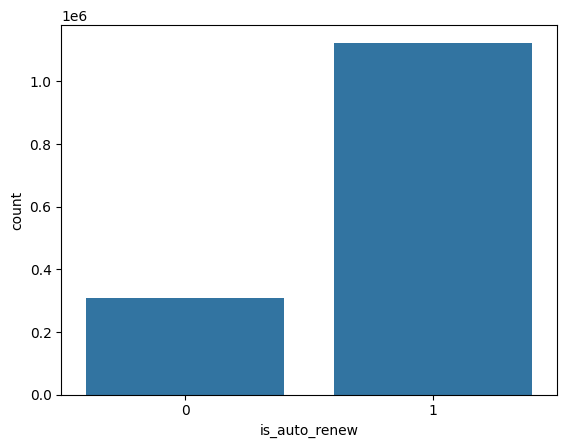

In [16]:
sns.countplot(x='is_auto_renew', data=transactions_df)
plt.show()

In [17]:
transactions_df.membership_expire_date = pd.to_datetime(transactions_df.membership_expire_date, format='%Y%m%d')
transactions_df.transaction_date = pd.to_datetime(transactions_df.transaction_date, format='%Y%m%d')

In [18]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1431009 entries, 0 to 1431008
Data columns (total 9 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   msno                    1431009 non-null  str           
 1   payment_method_id       1431009 non-null  int64         
 2   payment_plan_days       1431009 non-null  int64         
 3   plan_list_price         1431009 non-null  int64         
 4   actual_amount_paid      1431009 non-null  int64         
 5   is_auto_renew           1431009 non-null  int64         
 6   transaction_date        1431009 non-null  datetime64[us]
 7   membership_expire_date  1431009 non-null  datetime64[us]
 8   is_cancel               1431009 non-null  int64         
dtypes: datetime64[us](2), int64(6), str(1)
memory usage: 98.3 MB


In [19]:
transactions_df.membership_expire_date.max(), transactions_df.membership_expire_date.min()

(Timestamp('2036-10-15 00:00:00'), Timestamp('2016-04-19 00:00:00'))

In [20]:
transactions_df.transaction_date.max(), transactions_df.transaction_date.min()

(Timestamp('2017-03-31 00:00:00'), Timestamp('2015-01-01 00:00:00'))

## User Logs

In [21]:
user_logs_df = pd.read_csv(BASE_DIR / 'data' / 'user_logs_v2.csv')

user_logs_df.head(3)

,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,u9E91QDTvHLq6NXjEaWv8u4QIqhrHk72kE+w31Gnhdg=,20170331,8,4,0,1,21,18,6309.273
1,nTeWW/eOZA/UHKdD5L7DEqKKFTjaAj3ALLPoAWsU8n0=,20170330,2,2,1,0,9,11,2390.699
2,2UqkWXwZbIjs03dHLU9KHJNNEvEkZVzm69f3jCS+uLI=,20170331,52,3,5,3,84,110,23203.337


In [22]:
user_logs_df.shape

(18396362, 9)

In [23]:
user_logs_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18396362 entries, 0 to 18396361
Data columns (total 9 columns):
 #   Column      Dtype  
---  ------      -----  
 0   msno        str    
 1   date        int64  
 2   num_25      int64  
 3   num_50      int64  
 4   num_75      int64  
 5   num_985     int64  
 6   num_100     int64  
 7   num_unq     int64  
 8   total_secs  float64
dtypes: float64(1), int64(7), str(1)
memory usage: 1.2 GB


## Members

In [24]:
members_df = pd.read_csv(BASE_DIR / 'data' / 'members_v3.csv')

members_df.head(3)

,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915


In [25]:
members_df.gender.value_counts()

gender
male      1195355
female    1144613
Name: count, dtype: int64

In [26]:
members_df.isna().sum()

msno                            0
city                            0
bd                              0
gender                    4429505
registered_via                  0
registration_init_time          0
dtype: int64

In [29]:
members_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6769473 entries, 0 to 6769472
Data columns (total 6 columns):
 #   Column                  Dtype
---  ------                  -----
 0   msno                    str  
 1   city                    int64
 2   bd                      int64
 3   gender                  str  
 4   registered_via          int64
 5   registration_init_time  int64
dtypes: int64(4), str(2)
memory usage: 309.9 MB
